# Chorus Health - Model Training

The data that was cleaned and compiled in the previous notebook will be used here to train the chorus health model with machine learning. Multiple models are experimented with to determine the best type to use.

## Prepare the data

In [1]:
# Imports

import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, recall_score, precision_score

from sklearn.pipeline import Pipeline

from sklearn.svm import SVC

In [2]:
# Read the CSV
full_data = pd.read_csv('chorus_data_compiled.csv')

In [3]:
# Identify the relevant columns for a 2024 snapshot
columns_2024 = [
    'chorus_sc_code',
    'status',
    'active_members_2024',
    'active_members_2022',
    'two_year_growth_rate_2024',
    'avg_age_2024',
    'avg_age_2022',
    'two_year_age_change_2024',
    'single_quartet_rate_2024',
    'multi_quartet_rate_2024',
    'chapter_leader_density_2024',
    'former_chapter_leader_density_2024',
    'district_leader_density_2024',
    'former_district_leader_density_2024']

# Create a DataFrame for the 2024 snapshot with just the relevant columns
chorus_data_2024 = full_data[columns_2024]
chorus_data_2024.head()

,chorus_sc_code,status,active_members_2024,active_members_2022,two_year_growth_rate_2024,avg_age_2024,avg_age_2022,two_year_age_change_2024,single_quartet_rate_2024,multi_quartet_rate_2024,chapter_leader_density_2024,former_chapter_leader_density_2024,district_leader_density_2024,former_district_leader_density_2024
0,J047A,Active,158.0,160.0,-0.012500,63.341772,62.800000,0.541772,0.170886,0.474684,0.094937,0.474684,0.018987,0.088608
1,J033B,Active,3.0,2.0,0.500000,77.000000,79.000000,-2.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
2,NaN,Active,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,J113A,Active,4.0,5.0,-0.200000,76.250000,79.600000,-3.350000,0.000000,0.000000,0.000000,0.750000,0.000000,0.000000
4,J065A,Active,12.0,11.0,0.090909,69.500000,72.090909,-2.590909,0.250000,0.250000,0.250000,0.666667,0.000000,0.000000


In [4]:
# Identify the relevant columns for a 2026 snapshot
columns_2026 = [
    'chorus_sc_code',
    'status',
    'active_members_2026',
    'active_members_2024',
    'two_year_growth_rate_2026',
    'avg_age_2026',
    'avg_age_2024',
    'two_year_age_change_2026',
    'single_quartet_rate_2026',
    'multi_quartet_rate_2026',
    'chapter_leader_density_2026',
    'former_chapter_leader_density_2026',
    'district_leader_density_2026',
    'former_district_leader_density_2026']

# Create a DataFrame for the 2026 snapshot with just the relevant columns
chorus_data_2026 = full_data[columns_2026]
chorus_data_2026.head()

,chorus_sc_code,status,active_members_2026,active_members_2024,two_year_growth_rate_2026,avg_age_2026,avg_age_2024,two_year_age_change_2026,single_quartet_rate_2026,multi_quartet_rate_2026,chapter_leader_density_2026,former_chapter_leader_density_2026,district_leader_density_2026,former_district_leader_density_2026
0,J047A,Active,154.0,158.0,-0.025316,61.214286,63.341772,-2.127486,0.181818,0.448052,0.110390,0.422078,0.019481,0.077922
1,J033B,Active,3.0,3.0,0.000000,79.000000,77.000000,2.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
2,NaN,Active,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,J113A,Active,2.0,4.0,-0.500000,80.500000,76.250000,4.250000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
4,J065A,Active,7.0,12.0,-0.416667,75.428571,69.500000,5.928571,0.000000,0.285714,0.285714,0.571429,0.000000,0.000000


In [5]:
# Drop the rows with NaN
chorus_data_2024 = chorus_data_2024.dropna()
chorus_data_2026 = chorus_data_2026.dropna()

## Model 1: Classification

In [6]:
# Define the buckets
# 0 = Healthy, 1 = At-Risk
# At-Risk means the average age increased by 2+ or the count of total members is <12
# If the average ages increases by 2+ in the span of 2 years, this means that members are aging in place, or the only new members joining are older than the existing members. This means the chorus runs the risk of aging out and losing members as they get too old to participate or pass away, with no new members filling the gaps.
# This definition was also tested with just the size of the chorus, or with the size of the chorus or the two-year growth rate, but this version proved the most successful for the model.

def define_health(row):
    if row['active_members_2024'] < 12 or row['two_year_age_change_2024'] >= 2:
        return 1
    return 0

# Add a column for at-risk to the 2024 snapshot
chorus_data_2024['is_at_risk'] = chorus_data_2024.apply(define_health, axis=1)

# Count the number of at-risk choruses with this definition
print(f'Total at-risk choruses: {chorus_data_2024['is_at_risk'].sum()} out of {len(chorus_data_2024)}')

Total at-risk choruses: 31 out of 72


In [7]:
# Define the features and the target
# Note: This list evolved through experimentation. Other versions included combining current+former chapter leaders and current+former district leaders, but this smoothed out the data too much. 
features = [
    'avg_age_2024',
    'single_quartet_rate_2024',
    'multi_quartet_rate_2024',
    'chapter_leader_density_2024',
    'former_chapter_leader_density_2024',
    'district_leader_density_2024',
    'former_district_leader_density_2024',
    'two_year_growth_rate_2024'
]

X = chorus_data_2024[features].fillna(0)
y = chorus_data_2024['is_at_risk']

In [8]:
# Calculate correlations between features and the target
# Features with a positive value indicate that as the feature increases, risk of being unhealthy increases
# Features with a negative value indicate that as the feature increases, risk of being unhealthy decreases
correlations = chorus_data_2024[features + ['is_at_risk']].corr()['is_at_risk'].sort_values()

print(correlations)

former_district_leader_density_2024   -0.319067
multi_quartet_rate_2024               -0.305812
single_quartet_rate_2024              -0.191267
chapter_leader_density_2024           -0.115685
two_year_growth_rate_2024              0.097292
district_leader_density_2024           0.112276
avg_age_2024                           0.410193
former_chapter_leader_density_2024     0.455189
is_at_risk                             1.000000
Name: is_at_risk, dtype: float64


In [9]:
# Split the training and testing data
# Stratify to make sure both sets have an equal number of at-risk choruses

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

### Version A: RandomForestClassifier

This will provide a baseline without doing any hyperparameter tuning.

In [10]:
# Initialize the classifier
model_rfc = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

In [11]:
# Train the model
model_rfc.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [12]:
# Make predictions
y_pred_rfc = model_rfc.predict(X_test)

# Print the stats
print(classification_report(y_test, y_pred_rfc))

              precision    recall  f1-score   support

           0       0.69      0.90      0.78        10
           1       0.80      0.50      0.62         8

    accuracy                           0.72        18
   macro avg       0.75      0.70      0.70        18
weighted avg       0.74      0.72      0.71        18



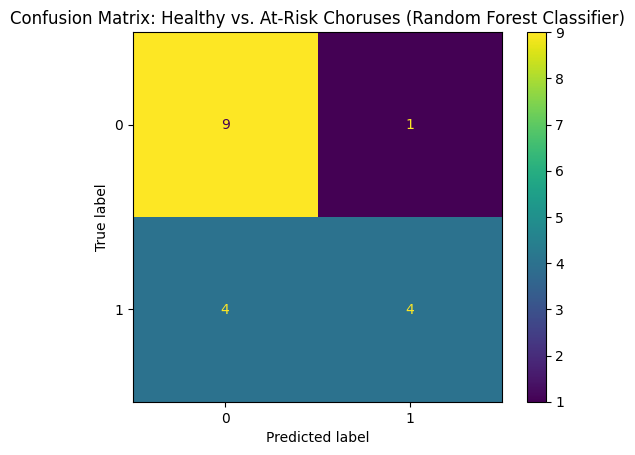

In [13]:
# Plot the confusion matrix for the test data
ConfusionMatrixDisplay.from_estimator(model_rfc, X_test, y_test)
plt.title('Confusion Matrix: Healthy vs. At-Risk Choruses (Random Forest Classifier)')
plt.show()

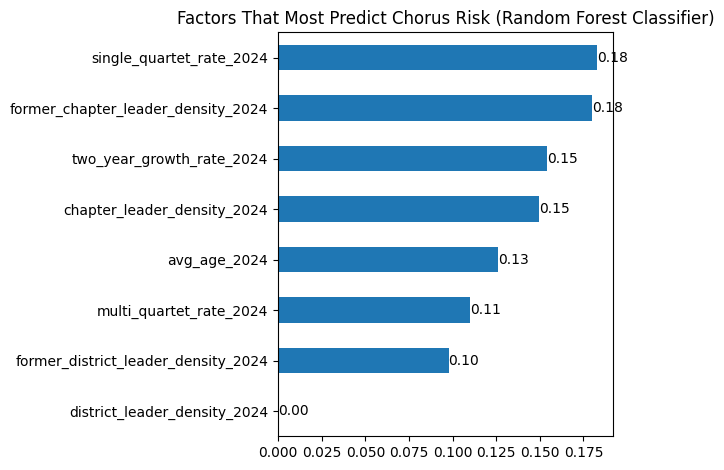

In [14]:
# Extract and plot feature importances
importances_rfc = model_rfc.feature_importances_
feature_names = X.columns
model_results_rfc = pd.Series(importances_rfc, index=feature_names).sort_values(ascending=True)

model_results_rfc.plot(kind='barh')
plt.title('Factors That Most Predict Chorus Risk (Random Forest Classifier)')
plt.bar_label(plt.gca().containers[0], fmt='%.2f')
plt.tight_layout()
plt.show()

### Version B: GridSearchCV

Use GridSearchCV to tune hyperparameters.

In [15]:
# Set up the parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 3, 5, 10],
    'min_samples_split': [2, 5, 10],
    'class_weight': ['balanced', 'balanced_subsample']
}

In [16]:
# Initialize the model
model_gs = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='f1')

In [17]:
# Fit the model
model_gs.fit(X_train, y_train)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'class_weight': ['balanced', 'balanced_subsample'], 'max_depth': [None, 3, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [50, 100, ...]}"
,scoring,'f1'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [18]:
# Extract the best version of the model
best_model_gs = model_gs.best_estimator_
print(f'Best Parameters: {model_gs.best_params_}')

Best Parameters: {'class_weight': 'balanced', 'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}


In [19]:
# Make predictions using the test set
y_pred_gs = best_model_gs.predict(X_test)

# Print the stats
print(classification_report(y_test, y_pred_gs))

              precision    recall  f1-score   support

           0       0.69      0.90      0.78        10
           1       0.80      0.50      0.62         8

    accuracy                           0.72        18
   macro avg       0.75      0.70      0.70        18
weighted avg       0.74      0.72      0.71        18



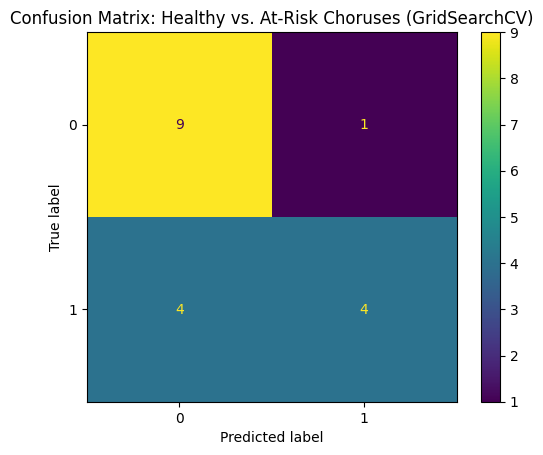

In [20]:
# Plot the confusion matrix for the test data
ConfusionMatrixDisplay.from_estimator(best_model_gs, X_test, y_test)
plt.title('Confusion Matrix: Healthy vs. At-Risk Choruses (GridSearchCV)')
plt.show()

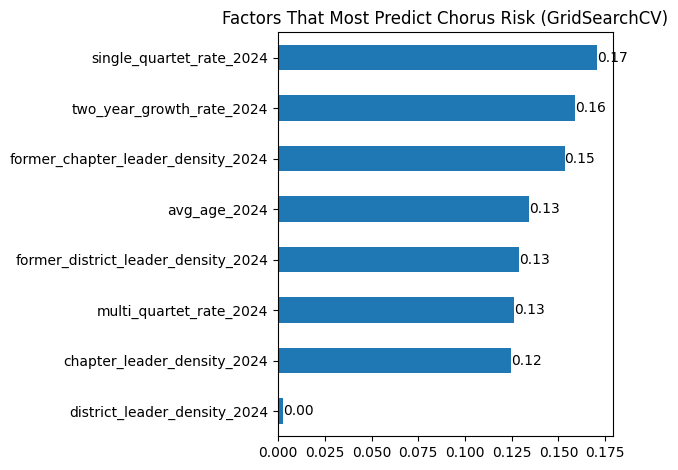

In [21]:
# Extract and plot feature importances
importances_gs = best_model_gs.feature_importances_
feature_names = X.columns
model_results_gs = pd.Series(importances_gs, index=feature_names).sort_values(ascending=True)

model_results_gs.plot(kind='barh')
plt.title('Factors That Most Predict Chorus Risk (GridSearchCV)')
plt.bar_label(plt.gca().containers[0], fmt='%.2f')
plt.tight_layout()
plt.show()

In [22]:
# Map the full list to see how the model bucketed them

# Run predictions on the full dataset
full_preds = best_model_gs.predict(X)
full_probs = best_model_gs.predict_proba(X)[:, 1]

# Create the full report
full_report = chorus_data_2024[['chorus_sc_code', 'active_members_2024', 'is_at_risk']].copy()
full_report['Model_Prediction'] = full_preds
full_report['Risk_Score'] = full_probs

# Define the buckets
full_report['Status'] = full_report['Model_Prediction'].map({1: 'Predicted At-Risk', 0: 'Predicted Healthy'})

# Print the full list, grouped by the original categorization of at-risk, the model prediction, and the model risk score
with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', None, 'expand_frame_repr', False):
    print(full_report.sort_values(by=['is_at_risk', 'Model_Prediction', 'Risk_Score']))

   chorus_sc_code  active_members_2024  is_at_risk  Model_Prediction  Risk_Score             Status
77          J046A                 25.0           0                 0       0.010  Predicted Healthy
58          J100A                 31.0           0                 0       0.020  Predicted Healthy
68          J022A                 55.0           0                 0       0.020  Predicted Healthy
18          J132A                 28.0           0                 0       0.030  Predicted Healthy
32          J036A                 28.0           0                 0       0.030  Predicted Healthy
28          J105A                 32.0           0                 0       0.035  Predicted Healthy
0           J047A                158.0           0                 0       0.040  Predicted Healthy
26          J082A                 43.0           0                 0       0.040  Predicted Healthy
54          J016A                 36.0           0                 0       0.045  Predicted Healthy


## Model 2: Classification (after dropping some data)

The above models show that in almost all cases, if member size is <12, the model would predict that the chorus is at-risk. This is not especially useful, because we already know those choruses are at-risk. The more useful information is about the choruses in the 12-15 member range, to know if they're trending downwards and might become unhealthy.

To adjust for this, we'll experiment with removing member size from the definition of healthy vs. at-risk and only base it on the average age growing faster than real time, and remove the choruses that are already <12 people from the training set. Then we'll use a RandomForestClassifier model again.

In [23]:
# Redefine the target
chorus_data_2024['is_aging'] = (chorus_data_2024['two_year_age_change_2024'] > 2).astype(int)

# Filter to only the choruses that have 12+ members
chorus_data_2024_filtered = chorus_data_2024[chorus_data_2024['active_members_2024'] >= 12].copy()

In [24]:
# Select features

features_v2 = [
    'avg_age_2024',
    'single_quartet_rate_2024',
    'multi_quartet_rate_2024',
    'chapter_leader_density_2024',
    'former_chapter_leader_density_2024',
    'district_leader_density_2024',
    'former_district_leader_density_2024',
    'two_year_growth_rate_2024'
]

X = chorus_data_2024_filtered[features_v2].fillna(0)
y = chorus_data_2024_filtered['is_aging']

In [25]:
# Calculate correlations between features and the target
# Features with a positive value indicate that as the feature increases, risk of being unhealthy increases
# Features with a negative value indicate that as the feature decreases, risk of being unhealthy decreases
correlations = chorus_data_2024_filtered[features_v2 + ['is_at_risk']].corr()['is_at_risk'].sort_values()

print(correlations)

former_district_leader_density_2024   -0.228826
multi_quartet_rate_2024               -0.209921
chapter_leader_density_2024           -0.071356
district_leader_density_2024           0.016834
former_chapter_leader_density_2024     0.228527
two_year_growth_rate_2024              0.241376
single_quartet_rate_2024               0.267510
avg_age_2024                           0.330191
is_at_risk                             1.000000
Name: is_at_risk, dtype: float64


In [26]:
# Split the data
X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(X, y, test_size=0.2, random_state=42)

In [27]:
# Initialize and fit the model
model_rfc_v2 = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)

model_rfc_v2.fit(X_train_v2, y_train_v2)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [28]:
# Make predictions
y_pred_rfc_v2 = model_rfc_v2.predict(X_test_v2)

# Print the stats
print(classification_report(y_test_v2, y_pred_rfc_v2))

              precision    recall  f1-score   support

           0       0.40      1.00      0.57         4
           1       1.00      0.14      0.25         7

    accuracy                           0.45        11
   macro avg       0.70      0.57      0.41        11
weighted avg       0.78      0.45      0.37        11



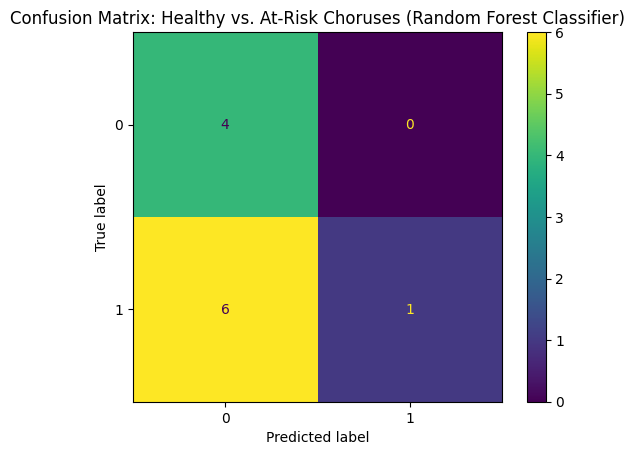

In [29]:
# Plot the confusion matrix for the test data
ConfusionMatrixDisplay.from_estimator(model_rfc_v2, X_test_v2, y_test_v2)
plt.title('Confusion Matrix: Healthy vs. At-Risk Choruses (Random Forest Classifier)')
plt.show()

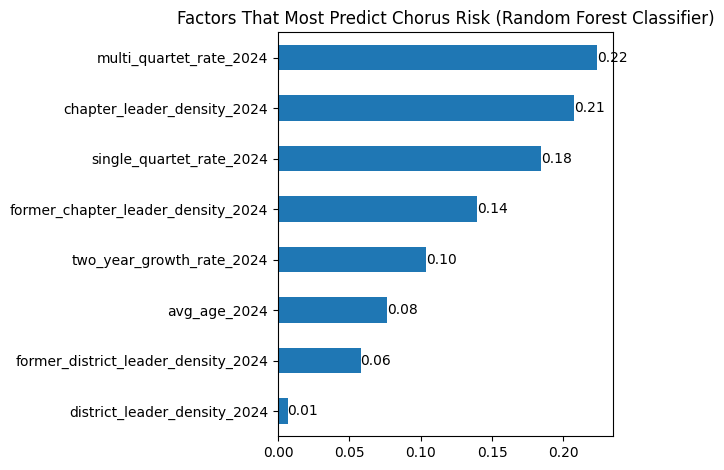

In [30]:
# Extract and plot feature importances
importances_rfc_v2 = model_rfc_v2.feature_importances_
feature_names_v2 = X.columns
model_results_rfc_v2 = pd.Series(importances_rfc_v2, index=feature_names_v2).sort_values(ascending=True)

model_results_rfc_v2.plot(kind='barh')
plt.title('Factors That Most Predict Chorus Risk (Random Forest Classifier)')
plt.bar_label(plt.gca().containers[0], fmt='%.2f')
plt.tight_layout()
plt.show()

### Use the patterns the model learned for 2022-2024 to apply this to 2026 data

This will theoretically show which choruses are currently behaving like the ones that failed in the past.

In [31]:
# Select the features
features_2026 = [
    'avg_age_2026', 
    'single_quartet_rate_2026', 
    'multi_quartet_rate_2026', 
    'chapter_leader_density_2026', 
    'former_chapter_leader_density_2026',
    'district_leader_density_2026',
    'former_district_leader_density_2026',
    'two_year_growth_rate_2026'
]

X_2026 = chorus_data_2026[features_2026].fillna(0)
X_2026.columns = X_train.columns

In [32]:
# Generate risk scores to show the degree of risk
chorus_data_2026['Risk_Score'] = best_model_gs.predict_proba(X_2026)[:, 1]

# Filter for choruses between 12 and 15 members, the ones to most keep an eye on
chorus_targets_2026 = chorus_data_2026[
    (chorus_data_2026['active_members_2026'] >= 12) & 
    (chorus_data_2026['active_members_2026'] < 15)
].sort_values(by='Risk_Score', ascending=False)

print(chorus_targets_2026[['chorus_sc_code', 'active_members_2026', 'Risk_Score']])

   chorus_sc_code  active_members_2026  Risk_Score
7           J110A                 14.0       0.895
67          J014A                 14.0       0.695
27          J032A                 14.0       0.605
59          J119A                 12.0       0.415
71          J061A                 13.0       0.395
22          J008A                 14.0       0.325
63          J016B                 14.0       0.255
73          J015A                 14.0       0.245
31          J021A                 14.0       0.140
55          J003A                 13.0       0.120


In [33]:
# Print a list of the most at-risk choruses and their key features
print('The five choruses with the highest risk scores as of 1/1/2026 are:')
print('\n')
print(chorus_targets_2026[['chorus_sc_code', 'Risk_Score', 'active_members_2026', 'two_year_growth_rate_2026', 'avg_age_2026', 'two_year_age_change_2026']][:5])

The five choruses with the highest risk scores as of 1/1/2026 are:


   chorus_sc_code  Risk_Score  active_members_2026  two_year_growth_rate_2026  \
7           J110A       0.895                 14.0                  -0.176471   
67          J014A       0.695                 14.0                  -0.300000   
27          J032A       0.605                 14.0                   0.000000   
59          J119A       0.415                 12.0                   0.090909   
71          J061A       0.395                 13.0                  -0.187500   

    avg_age_2026  two_year_age_change_2026  
7      82.142857                  2.554622  
67     77.500000                  4.700000  
27     76.642857                 -0.214286  
59     75.250000                  2.795455  
71     66.384615                 -1.115385  


## Model 3: Logistic Regression

Try a logistic regression model to predict the probability that a data point belongs to a specific category.

In [34]:
# Use a Pipeline to scale the data and then run the model
model_logreg = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(class_weight='balanced', random_state=42))
])

# Fit the model
model_logreg.fit(X_train, y_train)

,steps,"[('scaler', ...), ('logreg', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [35]:
# Get predictions on the test data
y_pred_logreg = model_logreg.predict(X_test)

In [36]:
# Calculate the feature importances
importances_logreg = pd.DataFrame({
    'Feature': features,
    'Coefficient': model_logreg.named_steps['logreg'].coef_[0]
}).sort_values(by='Coefficient')

print(importances_logreg)

                               Feature  Coefficient
6  former_district_leader_density_2024    -1.397857
1             single_quartet_rate_2024    -0.501223
3          chapter_leader_density_2024    -0.125507
2              multi_quartet_rate_2024     0.104425
5         district_leader_density_2024     0.265406
0                         avg_age_2024     0.500361
7            two_year_growth_rate_2024     0.762306
4   former_chapter_leader_density_2024     0.935274


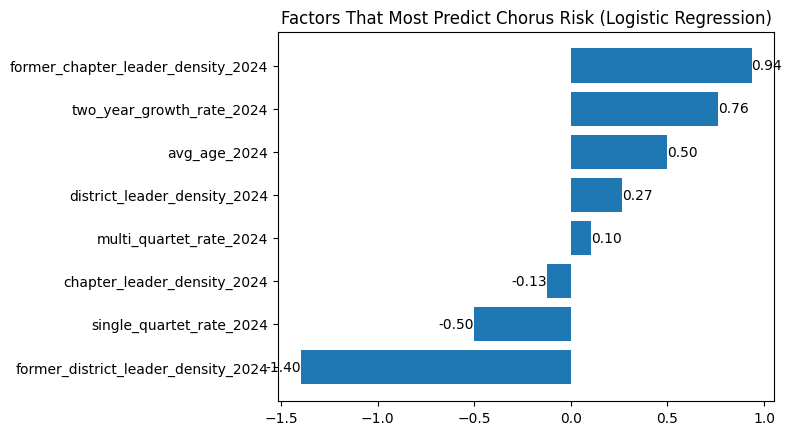

In [37]:
plt.barh(y=importances_logreg['Feature'], width=importances_logreg['Coefficient'])
plt.title('Factors That Most Predict Chorus Risk (Logistic Regression)')
plt.bar_label(plt.gca().containers[0], fmt='%.2f')
plt.show()

## Model 4: Support Vector Machine

Use a Support Vector Machine to find the optimal hyperplane that maximizes the margin between two classes.

In [38]:
# Use a Pipeline to scale the data and then run the model
model_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(probability=True, kernel='linear', class_weight='balanced', random_state=42))
])

# Fit the model
model_svm.fit(X_train, y_train)

,steps,"[('scaler', ...), ('svm', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'


In [39]:
# Get predictions on the test data
y_pred_svm = model_svm.predict(X_test)

In [40]:
# Get the feature importances
coefficients_svm = model_svm.named_steps['svm'].coef_[0]
importances_svm = pd.Series(np.abs(coefficients_svm), index=feature_names)

print(importances_svm.sort_values())

chapter_leader_density_2024            0.062330
avg_age_2024                           0.355555
multi_quartet_rate_2024                0.368988
district_leader_density_2024           0.437702
two_year_growth_rate_2024              0.437853
single_quartet_rate_2024               0.467774
former_chapter_leader_density_2024     0.621337
former_district_leader_density_2024    1.268809
dtype: float64


## Compare the models and choose the best one

In [41]:
# Define the metrics to get from each model
def get_metrics(name, y_true, y_pred):
    return {
        'Model': name,
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1 Score': f1_score(y_true, y_pred)
    }

In [42]:
# Collect all of the metrics into a list
model_metrics_list = []

model_metrics_list.append(get_metrics('Random Forest', y_test, y_pred_rfc))
model_metrics_list.append(get_metrics('Random Forest with GridSearch', y_test, y_pred_gs))
model_metrics_list.append(get_metrics('Logistic Regression', y_test, y_pred_logreg))
model_metrics_list.append(get_metrics('SVM', y_test, y_pred_svm))

# Convert the list into a DataFrame
model_metrics_df = pd.DataFrame(model_metrics_list)

For this business problem, Recall is the best metric to use. Recall measures the ability to find all positive instances. The cost of a False Negative is high in this scenario. If a chorus is actually at risk but the model says they aren't, that means district leadership might not pay attention to that chorus until it is too late.

Precision is a less important metric for this business problem. Precision measures how many predicted positives are actually positive. In this scenario, False Positives are less of an issue. If a chorus is actually healthy but the model says they're at-risk, they may unnecessarily get more attention from district leadership, but this isn't a bad thing on its own. If there is a particularly high rate of False Positives, this could be an issue because district leadership might not have enough attention to spread out across all the choruses indicated to be at-risk, but for the number of choruses involved, this is less likely to be an issue.

The F1 score should also be reviewed because this balances the trade-off between Precision and Recall.

In [43]:
# Sort by the models by Recall first and then F1 Score
model_metrics_df = model_metrics_df.sort_values(by=['Recall', 'F1 Score'], ascending=False)

# Find the best model based on Recall
best_model_row = model_metrics_df.iloc[0]

print(f"The best model for this scenario is: {best_model_row['Model']}")
print(f"Recall: {best_model_row['Recall']:.4f}")
print(f"Precision: {best_model_row['Precision']:.4f}")
print(f"F1: {best_model_row['F1 Score']:.4f}")

The best model for this scenario is: Logistic Regression
Recall: 0.8750
Precision: 0.7778
F1: 0.8235


In [44]:
# Extract the best model to use for 2026 predictions
model_map = {
    'Random Forest': model_rfc,
    'Random Forest with GridSearch': best_model_gs,
    'Logistic Regression': model_logreg,
    'SVM': model_svm
}

best_model_final = model_map[best_model_row['Model']]

In [45]:
# Show the feature importances for the best model

if best_model_final == model_logreg:
    best_feature_importances = importances_logreg
elif best_model_final == model_gs:
    best_feature_importances = importances_gs
elif best_model_final == model_rfc:
    best_feature_importances = importances_rfc
elif best_model_final == model_svm:
    best_feature_importances = importances_svm
else:
    print('No feature importances found.')

print(best_feature_importances)

                               Feature  Coefficient
6  former_district_leader_density_2024    -1.397857
1             single_quartet_rate_2024    -0.501223
3          chapter_leader_density_2024    -0.125507
2              multi_quartet_rate_2024     0.104425
5         district_leader_density_2024     0.265406
0                         avg_age_2024     0.500361
7            two_year_growth_rate_2024     0.762306
4   former_chapter_leader_density_2024     0.935274


In [46]:
# Generate risk scores to show the degree of risk
chorus_data_2026['Risk_Score'] = best_model_final.predict_proba(X_2026)[:, 1]

# Filter for choruses between 12 and 15 members, the ones to most keep an eye on
chorus_targets_2026 = chorus_data_2026[
    (chorus_data_2026['active_members_2026'] >= 12) & 
    (chorus_data_2026['active_members_2026'] < 15)
].sort_values(by='Risk_Score', ascending=False)

print('The choruses between 12-15 members that are most at risk as of 1/1/2026 are:')
print(chorus_targets_2026[['chorus_sc_code', 'active_members_2026', 'Risk_Score']])

The choruses between 12-15 members that are most at risk as of 1/1/2026 are:
   chorus_sc_code  active_members_2026  Risk_Score
7           J110A                 14.0    0.825492
22          J008A                 14.0    0.782289
67          J014A                 14.0    0.745199
27          J032A                 14.0    0.729443
71          J061A                 13.0    0.620132
73          J015A                 14.0    0.495478
59          J119A                 12.0    0.407217
63          J016B                 14.0    0.328930
55          J003A                 13.0    0.191137
31          J021A                 14.0    0.023081


## Conclusions

Based on the metrics calculated above, the Logistic Regression model performed the best when focusing on Recall. When using this model, the features that are most important are:
* Former District Leader Density: As this increases, the risk of an unhealthy chorus decreases. This could indicate that members who were formerly in district leadership continue to act as "culture carriers" for their chorus, whether that's by bringing in new members or by otherwise keeping the chorus active.
* Former Chapter Leader Density: On the flip side, as this increases, the risk of an unhealthy chorus increases. This could indicate that being a Chapter Leader in the past leads to burnout, and potentially leads to members leaving their choruses.
* Average Age: As this increases, the risk of an unhealthy chorus increases. This is what we understand intuitively to be true -- if the average age of a chorus keeps increasing, that means that either membership is stable and aging in place, or that the only new members joining (whether replacing departing members or not) are older than the existing average age.
* Growth Rate: Counterintuitively, as this increases, the risk of an unhealthy chorus also increases. This could be an indicator of unstable growth, like a bounce-back from the pandemic that faded by 2024, or members joining who weren't retained.

District leaders should use this data to inform how to help at-risk choruses. When recruiting new members for struggling choruses, they could look to members who are part of multiple quartets but perhaps haven't found a chorus to sing with. They should also keep in mind the existing average age, and focus on adding new members who are younger than that average. 